# Activation Functions (TensorFlow / Keras)

Activation functions introduce non-linearity between layers, which is what lets an
[`ANN`](../02_ANN) learn non-linear decision boundaries instead of just a linear
mapping. We first plot the three most common activations, then train the **same**
64->32->10 MLP on the `sklearn` digits dataset three times — once per activation —
to see how the choice affects training.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(0)

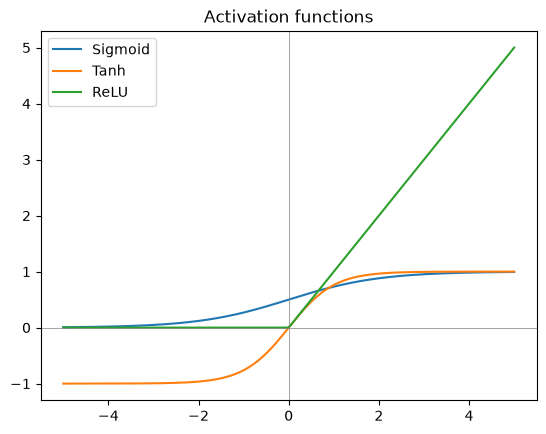

In [2]:
x = np.linspace(-5, 5, 200).astype("float32")
fig, ax = plt.subplots()
ax.plot(x, tf.sigmoid(x), label="Sigmoid")
ax.plot(x, tf.tanh(x), label="Tanh")
ax.plot(x, tf.nn.relu(x), label="ReLU")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.legend()
ax.set_title("Activation functions")
plt.show()

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


def make_model(activation):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64,)),
        tf.keras.layers.Dense(64, activation=activation),
        tf.keras.layers.Dense(32, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])


activations = {"Sigmoid": "sigmoid", "Tanh": "tanh", "ReLU": "relu"}

In [4]:
results = {}
for name, act in activations.items():
    tf.random.set_seed(0)
    model = make_model(act)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    history = model.fit(X_train, y_train, epochs=60, verbose=0)
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = {"losses": history.history["loss"], "accuracy": acc}
    print(f"{name:8s} final loss {history.history['loss'][-1]:.4f}  test accuracy {acc:.3f}")

Sigmoid  final loss 0.0004  test accuracy 0.972


Tanh     final loss 0.0001  test accuracy 0.972


ReLU     final loss 0.0000  test accuracy 0.978


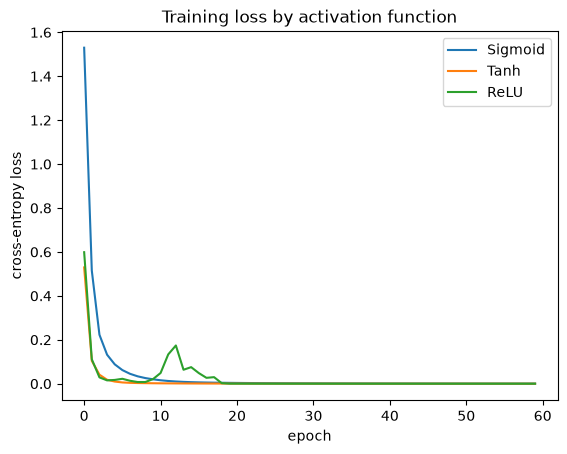

In [5]:
plt.figure()
for name, r in results.items():
    plt.plot(r["losses"], label=name)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Training loss by activation function")
plt.legend()
plt.show()